# Stacking

This notebook demonstrates how to perform image stacking using the EZPhot package. Image stacking is a fundamental technique in astronomical image processing that combines multiple exposures to improve signal-to-noise ratio and reduce noise.

## 1. Load Data

- Use the `DataBrowser` class to query and filter images
- Load science images for processing

> **💡 Optional Tip**: The `SDTDataQuerier` class provides methods to sync data from a central database to your local workspace, making it easy to work with large astronomical datasets.

<br><br>

### 🔍 1.1. Sync the data with SDTDataQuerier (Optional)


In [ ]:
# If you connected the database, you can easily sync the data from the database. 
from ezphot.utils import SDTDataQuerier
sdtquery = SDTDataQuerier()
sdtquery.help()
target_name = 'T00528'

In [ ]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_SCISOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_SCIDESTDIR'])
sdtquery.sync_scidata(
    targetname = target_name,
    file_pattern = '*.fits',
    ignore_exists = True
)

**🔄 Sync Progress**: The rsync process copies FITS files from the source directory to your local destination directory.


<br><br>

###  1.2. Query Data with DataBrowser

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


In [2]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 

from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)

observatory {'7DT'}
telkey {'7DT_C361K_HIGH_1x1'}
objname {'T01428', 'T05281', 'T03073', 'T08679', 'T13496', 'T01505', 'T04803', 'T11971', 'T01701', 'T11109', 'T11898', 'T03458', 'T21330', 'T03704', 'T21733', 'T12053', 'T02072', 'T23736', 'T13541', 'T25303', 'T00405', 'T04237', 'T13707', 'T21610', 'T13280', 'T11882', 'T07128', 'T23189', 'T13257', 'T13824', 'T23142', 'T22924', 'T11112', 'T11573', 'T00465', 'T24028', 'T03377', 'T00596', 'T09040', 'T01161', 'T00527', 'T10413', 'T03768', 'T00529', 'T25223', 'T07169', 'T03209', 'T12025', 'T24225', 'T14712', 'T00463', 'T24735', 'T10452', 'T00577', 'T05004', 'T17321', 'T00486', 'T03898', 'T09543', 'T06269', 'T15434', 'T03580', 'T02349', 'T09370', 'T13520', 'T15696', 'T01580', 'T03263', 'T12165', 'T01314', 'T09373', 'T00311', 'T24558', 'T05107', 'T14943', 'T06467', 'T23132', 'T01933', 'T10856', 'T16724', 'T23968', 'T09041', 'T02595', 'T05376', 'T02452', 'T13557', 'T13072', 'T08643', 'T23977', 'T00290', 'T00528', 'T13825', 'T03051', 'T13558', '

Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Filter**: m600
- **Pattern**: Files ending with `*100.fits`


In [5]:
dbrowser.objname = 'T00528'
dbrowser.filter = 'm600'
dbrowser.search('*100.fits', return_type = 'path')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


['/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_234441_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_072423_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250831_235542_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_074036_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_235531_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250904_234659_m600_100.fits',
 '/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/cal

In [6]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*100.fits', return_type = 'imginfo')

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 62.07it/s]


[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/*/m600/*100.fits'
Loaded 90 FITS files from /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
Total FITS files combined: 90


In [7]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str126,str32,str32,str32,str21,str4,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str9,str5
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,43.226146,177.841909,-10.1,2750,m600,LIGHT,100.0,2025-09-06T02:58:55.000,2025-09-05 22:58:55.000,2460924.624247685,60924.124247685184,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_234441_m600_100.fits,36.655996,166.440658,-10.1,2750,m600,LIGHT,100.0,2025-09-03T23:44:41.000,2025-09-03 19:44:41.000,2460922.489363426,60921.98936342593,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_072423_m600_100.fits,37.102087,193.288747,-10.1,2750,m600,LIGHT,100.0,2025-09-02T07:24:23.000,2025-09-02 03:24:23.000,2460920.8085995372,60920.308599537035,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250831_235542_m600_100.fits,36.617178,166.418143,-10.0,2750,m600,LIGHT,100.0,2025-08-31T23:55:42.000,2025-08-31 19:55:42.000,2460919.497013889,60918.99701388889,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_074036_m600_100.fits,36.283207,193.763747,-10.1,2750,m600,LIGHT,100.0,2025-09-02T07:40:36.000,2025-09-02 03:40:36.000,2460920.819861111,60920.319861111115,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250903_235531_m600_100.fits,37.198191,166.77371,-10.1,2750,m600,LIGHT,100.0,2025-09-03T23:55:31.000,2025-09-03 19:55:31.000,2460922.496886574,60921.996886574074,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250904_234659_m600_100.fits,36.969771,166.628158,-10.1,2750,m600,LIGHT,100.0,2025-09-04T23:46:59.000,2025-09-04 19:46:59.000,2460923.4909606483,60922.990960648145,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250902_073848_m600_100.fits,36.375758,193.714859,-10.0,2750,m600,LIGHT,100.0,2025-09-02T07:38:48.000,2025-09-02 03:38:48.000,2460920.818611111,60920.31861111111,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14
/home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_235138_m600_100.fits,37.585349,167.040065,-10.0,2750,m600,LIGHT,100.0,2025-09-06T23:51:38.000,2025-09-06 19:51:38.000,2460925.4941898147,60924.99418981482,1,T00528,1d2f12912f6841dc9ad12497eef6268e,Spec,specall,S250830bp,7DT14


<br><br>
<br><br>

## 2. Check Your Images

Now that we have loaded our data, let's inspect the images to understand their properties and quality:

> **Memory Warning**: Astronomical images can be large. Always use `ScienceImage.clear()` to free memory when you're done with an image.

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT14_T00528_20250906_025855_m600_100.fits'}>)

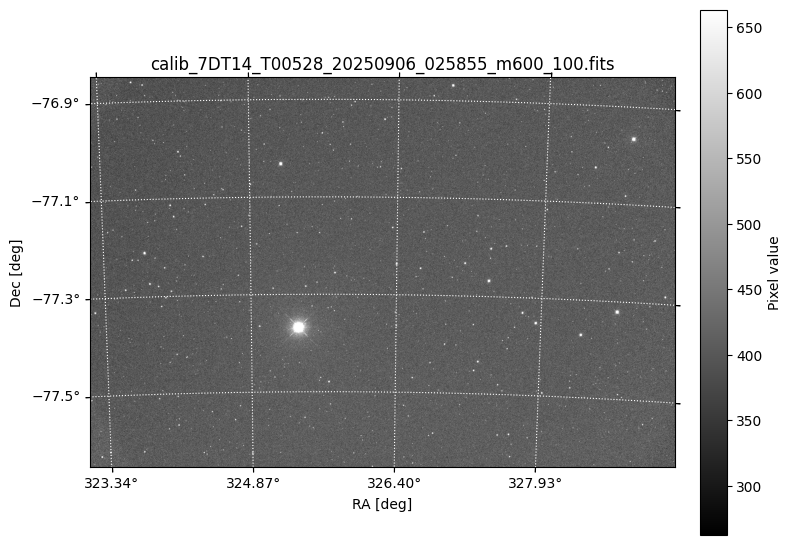

In [8]:
target_img = target_imglist[0]
target_img.show('coord')

In [9]:
# [CAUTION] For memory management, NOTE the below example.
# When you run any functions that load the data, all data are stored in the memory (data_load = True).
target_img

ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = True,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = m600,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)

Use `ScienceImage.clear()` to free memory when you're done with an image:

In [10]:
#To clear the memory, run ScienceImage.clear()
target_img.clear()
target_img

Cleared data and/or header from memory.


ScienceImage(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  imgtype     = LIGHT,
  exptime     = 100.0,
  filter      = m600,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)

In [11]:
# You can check the image with ds9 if X11 forward is available (via SSH)
target_img.run_ds9()

Running "ds9 -scalemode zscale -scale lock yes -frame lock image /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits &" in the terminal...


bash: cannot set terminal process group (2263633): Inappropriate ioctl for device
bash: no job control in this shell


<br><br>
<br><br>

## 3. Background Estimation

Background estimation is crucial for accurate photometry and image analysis. Here we are going to repeat the procedure in :doc:`example/backgroundestimation`.

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background estimation

> **Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.

<br><br>

### 3.1. Background estimation


[1] 2994589
application-specific initialization failed: no display name and no $DISPLAY environment variable
Unable to initialize window system.


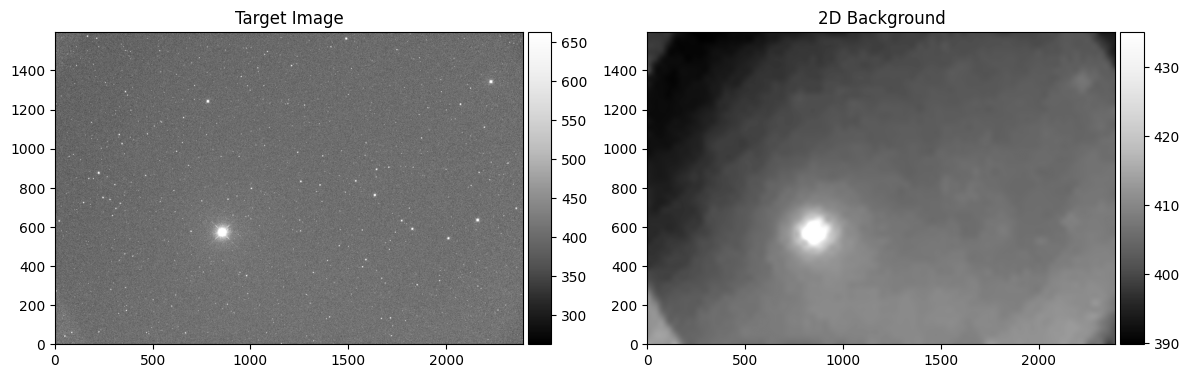

Cleared data and header from memory.


In [12]:
# Calculate the background map
target_bkg = target_img.calculate_bkg(
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkg.clear(verbose = True)

<br><br>

### 3.2. Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


#### 3.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]
2948 non-saturated, 13 saturated sources
2961 sources masked.


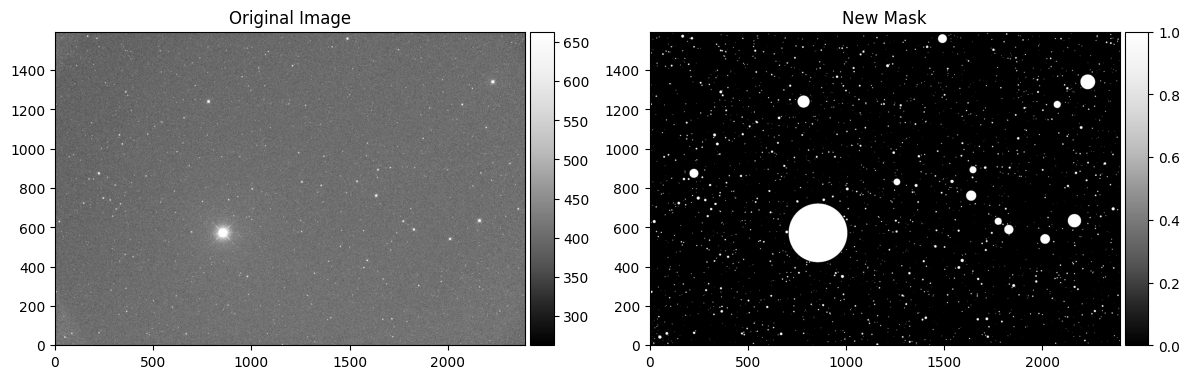

In [13]:
target_srcmask = target_img.calculate_sourcemask(
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)

#### 3.2.2. Re-generation of Background Map with Source Mask


External mask is loaded.


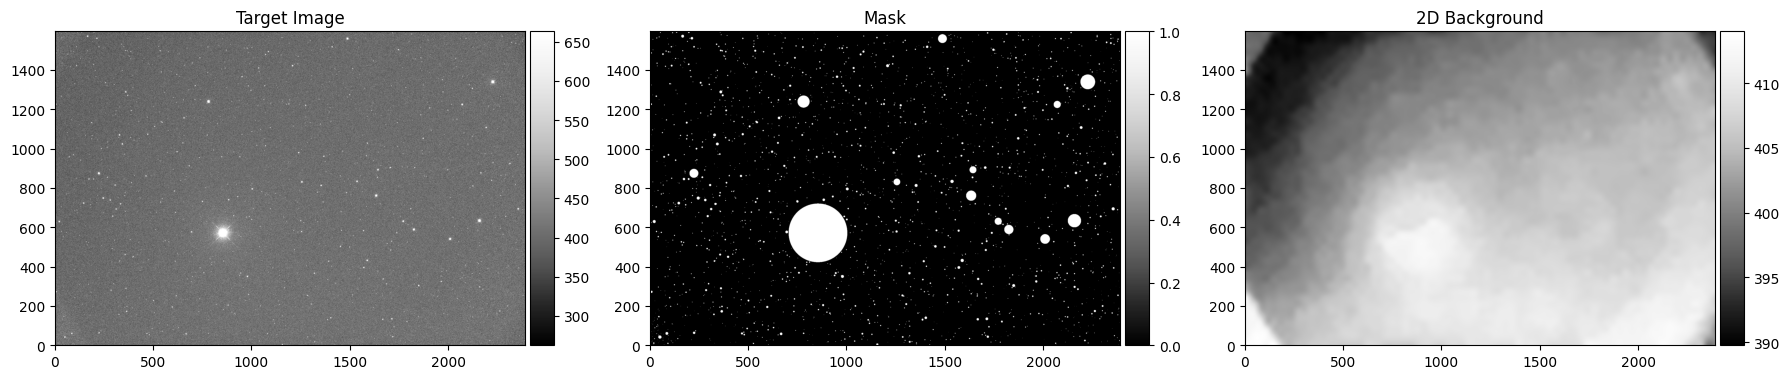

In [14]:
target_bkg_with_srcmask = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
)

In [15]:
# Write and clear the memory
target_srcmask.write()
target_bkg_with_srcmask.write()
target_srcmask.clear()
target_bkg_with_srcmask.clear()

# After writing the files, you can access to the files as attributes of the ScienceImage object.
print(target_img.bkgmap)
print(target_img.sourcemask)

Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.srcmask
Saved: /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.bkgmap
Cleared data and header from memory.
Cleared data and header from memory.
Background(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.bkgmap,
  savedir     = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600
)
Mask(
  is_exists   = True,
  is_saved    = True,
  data_load   = False,
  header_load = True,
  path        = /home/hhchoi1022/ezphot/data/scidata/7DT/7DT_C361K_HIGH_1x1/T00528/7DT14/m600/calib_7DT14_T00528_20250906_025855_m600_100.fits.srcmask,
  savedir     = /home/hhchoi1022/ezphot/data/sci

In [ ]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkg(target_img):    
    target_srcmask = target_img.calculate_sourcemask(   
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_img.calculate_bkg(
        target_srcmask = target_srcmask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )    
                
    target_srcmask.clear(verbose = False)
    target_bkg.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkg, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating backgrounds"))


<br><br>
<br><br>

## 4. Image stacking

Image stacking is possible with Stack class in ezphot. There are multiple options available before stacking

- **Background subtraction** (when target_bkglist is not None)
- **Zeropoint scaling** to match the level of flux between multiple images (when scale == True, ZP_key must exist in the header. To update ZP information, run photometriccalibration before this process)
- **Image convolution** to match the PSF size of multiple images (when convolve == True, seeing_key must exist in the header. To update SEEING information, run photometriccalibration before this process)

> **Science Note**: You can also stack Background RMS map by target_bkgrmslist parameters. 

<br><br>

### 4.1. Image stacking

In [16]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

In [19]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
stacked_img, _ = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Performing image reprojection...: 100%|██████████████████████████| 90/90 [02:22]


(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'calib_7DT14_T00528_20250906_025855_m600_100.com.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

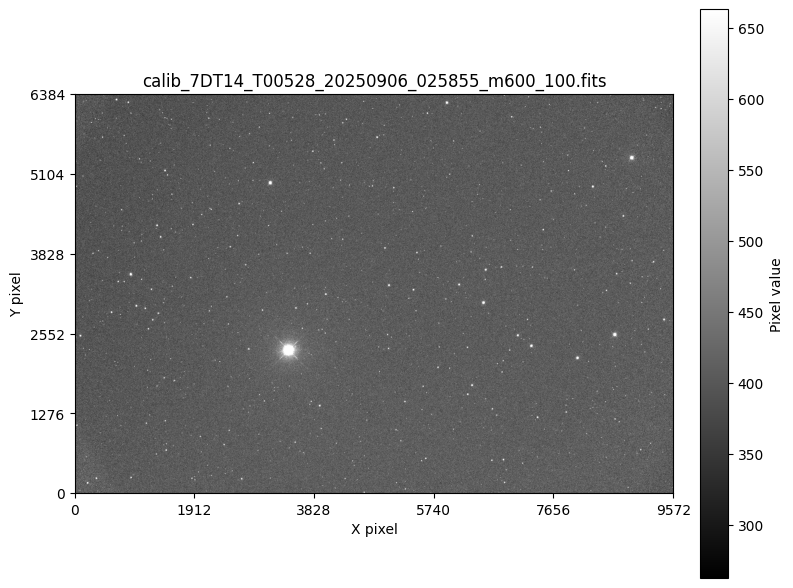

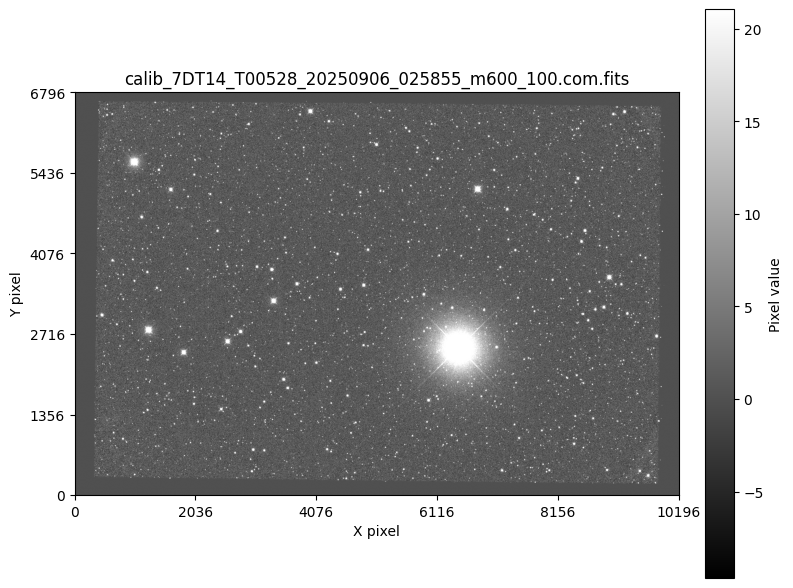

In [20]:
target_img.show()
stacked_img.show()

<br><br>

### 4.2. Image and Background RMS stacking 

In [22]:
from multiprocessing import Pool
from tqdm import tqdm
from ezphot.methods import Preprocess
preprocessor = Preprocess()
def calculate_bkgrms(target_img):
    mbias = preprocessor.get_masterframe_from_image(target_img, 'BIAS', 60)[0]
    mdark = preprocessor.get_masterframe_from_image(target_img, 'DARK', 60)[0]
    mflat = preprocessor.get_masterframe_from_image(target_img, 'FLAT', 60)[0]
    target_bkgrms = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap,
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_bkgrms.clear(verbose = False)
    mbias.clear(verbose = False)
    mdark.clear(verbose = False)
    mflat.clear(verbose = False)

with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    target_bkgrmslist = list(tqdm(pool.imap(calculate_bkgrms, target_imglist), 
                                  total=len(target_imglist), 
                                  desc="Calculating background RMS"))

Calculating background RMS: 100%|██████████| 90/90 [02:15<00:00,  1.50s/it]


In [23]:
from ezphot.methods import Stack

stacker = Stack()
stacker.help()

Help for Stack


Public methods:
- match_seeing(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, target_bkglist: Optional[List[ezphot.imageobjects.background.Background]] = None, seeing_key: str = 'SEEING', kernel: str = 'gaussian', save: bool = False, overwrite: bool = False, visualize: bool = True, verbose: bool = True, **kwargs)
- match_zeropoints(target_imglist: List[Union[ezphot.imageobjects.scienceimage.ScienceImage, ezphot.imageobjects.calibrationimage.CalibrationImage]], target_errormaplist: Optional[List[ezphot.imageobjects.errormap.Errormap]] = None, method: str = 'median', zp_key: str = 'ZP_APER_1', save: bool = False, overwrite: bool = False, verbose: bool = True, n_proc: int = 8, **kwargs)
- select_quality_images(target_imglist: Union[List[ezphot.imageobjects.scienceimage.ScienceImage], List[ezphot.imageobjects

In [24]:
target_imglist = target_imgset.target_images
target_bkglist = target_imgset.bkgmap
target_bkgrmslist = target_imgset.bkgrms
stacked_img, stacked_bkgrms = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    target_bkgrmslist = target_bkgrmslist,
    n_proc = 16,
    scale = False,
    convolve = False,
    save = True,
    verbose = False,
)

Performing image/bkgrms reprojection...: 100%|███████████████████| 90/90 [04:34]


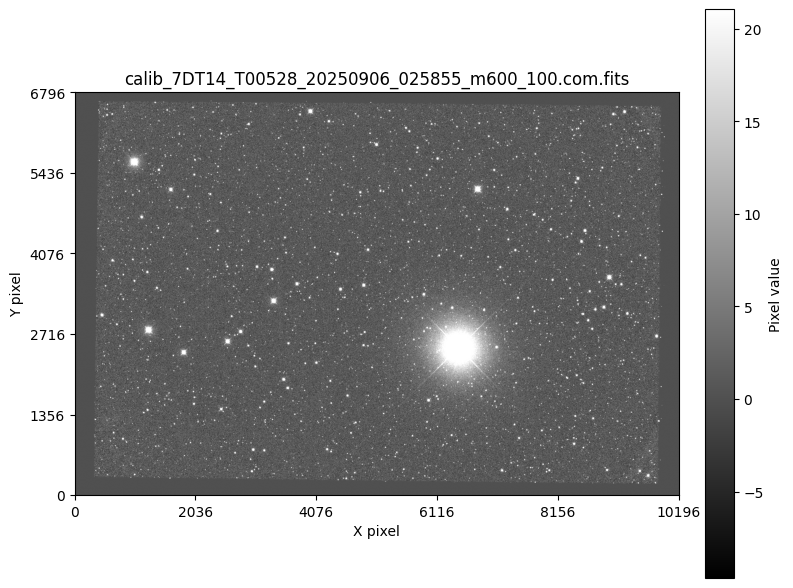

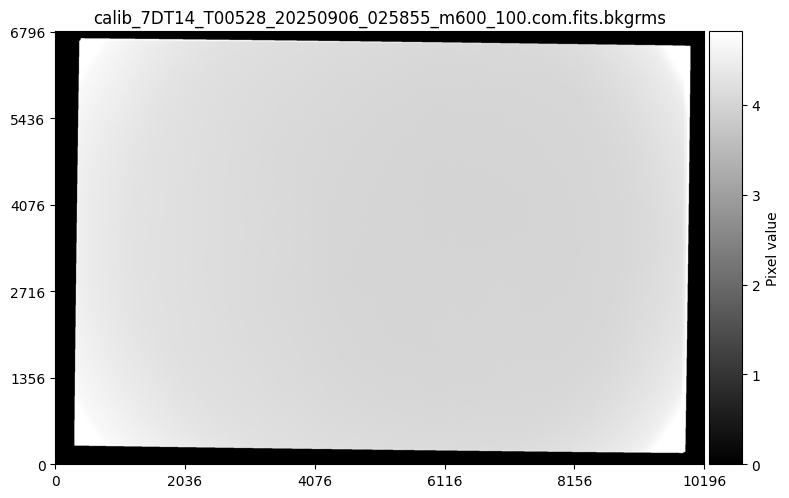

In [26]:
stacked_img.show()
stacked_bkgrms.show()

<br><br>

### 4.3. Image stacking with convolution or ZP scaling 
To do this, please refer Example `Photometric Calibration`.
 
You can apply FWHM matching and ZP matching after running photometric_calibration process. 

In [ ]:
for target_img in target_imglist:
    print("ZP of ", target_img.path.name, ":", target_img.header['ZP_APER_1']) 

In [28]:
stacked_img, stackged_bkgrms = stacker.stack_multiprocess(
    target_imglist = target_imglist,
    target_bkglist = target_bkglist,
    target_bkgrmslist = target_bkgrmslist,
    n_proc = 16,
    scale = True, # If you want to apply ZP matching, set scale = True
    scaled_type = 'min',
    zp_key = 'ZP_APER_1',
    convolve = False, # If you want to apply FWHM matching, set convolve = True
    save = True,
    verbose = False,
)

Subtracting background...: 100%|█████████████████████████████████| 90/90 [04:50]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()